In [1]:
import pandas as pd
import sys
import os
import lightkurve
from context import LCWavelet
from context import binning


In [2]:
csv_results = pd.read_csv('candidates_predictions.csv')
csv_results

,id,kepler_name,predicted,probability
0,candidate_1,K04902.01,0.0,3.516619e-13
1,candidate_2,K04146.02,1.0,9.998909e-01
2,candidate_3,K07270.01,0.0,1.554602e-01
3,candidate_4,K04519.01,0.0,3.113665e-13
4,candidate_5,K01940.02,1.0,9.352825e-01
...,...,...,...,...
1950,candidate_1951,K02018.02,0.0,3.973443e-01
1951,candidate_1952,K06214.02,0.0,2.966342e-16
1952,candidate_1953,K05748.01,0.0,2.209761e-07
1953,candidate_1954,K05749.01,0.0,4.498838e-08


In [3]:
# buscar los candidatos en all_data
kepler_names = csv_results['kepler_name'].unique()
all_data_path = '../all_data_2025_dmey'
candidates = list()

files = [f for f in os.listdir(all_data_path) if f.endswith('.pickle')]
files_dict = {str(f.split('-')[1].split('.')[0].replace('_', '.')): f for f in files}

for kepler_name in kepler_names:
    if kepler_name in files_dict:
        candidates.append(files_dict[kepler_name])

print(len(candidates), 'candidates found in all_data')

1955 candidates found in all_data


In [4]:
# comparar un transito con probabilidad alta de exoplaneta 0.99, uno bajo 0.01 y uno intermedio
alta_prob = csv_results[csv_results['probability'] >= 0.99]
baja_prob = csv_results[csv_results['probability'] <= 0.01]
intermedia_prob = csv_results[(csv_results['probability'] >= 0.4) & (csv_results['probability'] <= 0.6)]

alta_prob_series = alta_prob['kepler_name'].values[1]
baja_prob_series = baja_prob['kepler_name'].values[0]
intermedia_prob_series = intermedia_prob['kepler_name'].values[0]
print('Alta probabilidad:', alta_prob_series)
print('Baja probabilidad:', baja_prob_series)
print('Intermedia probabilidad:', intermedia_prob_series)


Alta probabilidad: K00426.01
Baja probabilidad: K04902.01
Intermedia probabilidad: K02689.01


In [5]:
# cargar los datos de los candidatos y plot
alta_prob_data = LCWavelet.LightCurveWaveletGlobalLocalCollection.from_pickle(os.path.join(all_data_path, files_dict[alta_prob_series]))
baja_prob_data = LCWavelet.LightCurveWaveletGlobalLocalCollection.from_pickle(os.path.join(all_data_path, files_dict[baja_prob_series]))
intermedia_prob_data = LCWavelet.LightCurveWaveletGlobalLocalCollection.from_pickle(os.path.join(all_data_path, files_dict[intermedia_prob_series]))

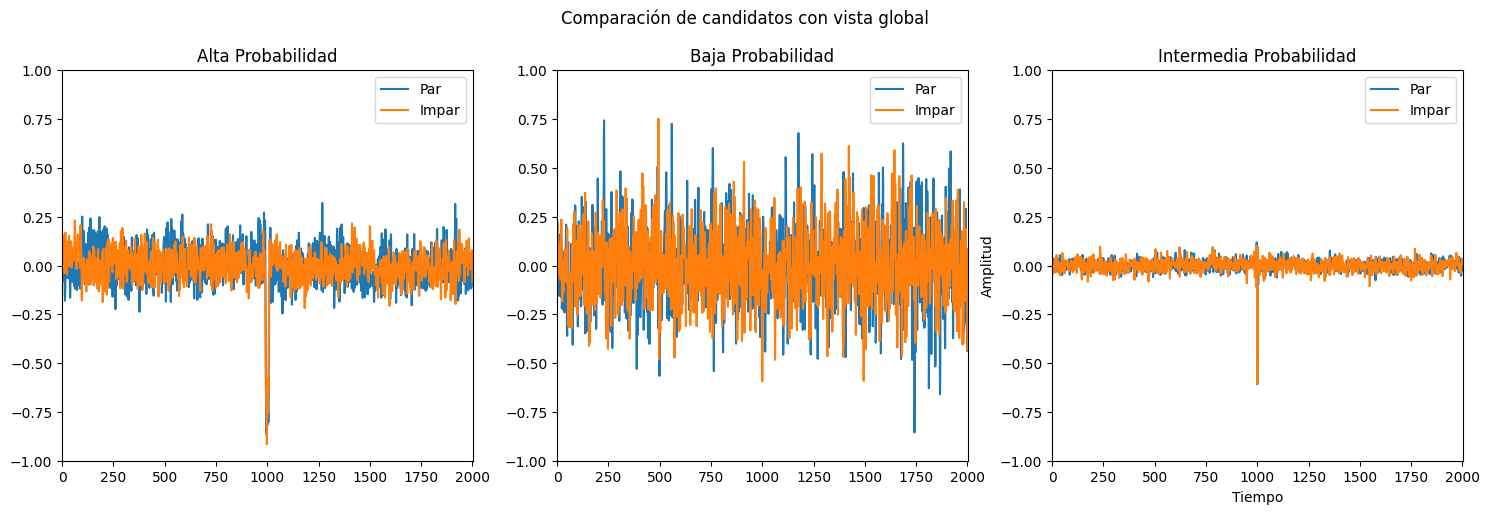

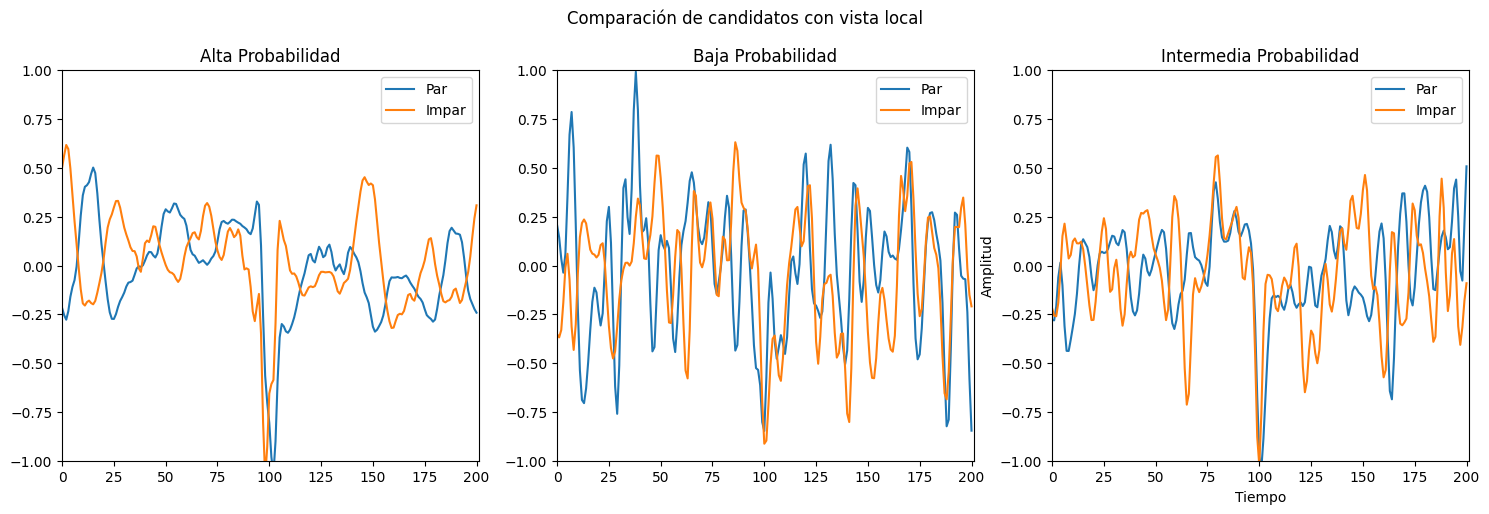

In [9]:
import matplotlib.pyplot as plt
level = 1

plt.figure(figsize=(15, 5))
plt.suptitle('Comparación de candidatos con vista global')
plt.subplot(1, 3, 1)
plt.plot(alta_prob_data.pliegue_par_global.get_approximation_coefficent(level))
plt.plot(alta_prob_data.pliegue_impar_global.get_approximation_coefficent(level))
plt.legend(['Par', 'Impar'])
plt.title('Alta Probabilidad')
plt.xlim(0, 2001)
plt.ylim(-1, 1)

plt.subplot(1, 3, 2)
plt.plot(baja_prob_data.pliegue_par_global.get_approximation_coefficent(level))
plt.plot(baja_prob_data.pliegue_impar_global.get_approximation_coefficent(level))
plt.legend(['Par', 'Impar'])
plt.title('Baja Probabilidad')
plt.xlim(0, 2001)
plt.ylim(-1, 1)

plt.subplot(1, 3, 3)
plt.plot(intermedia_prob_data.pliegue_par_global.get_approximation_coefficent(level))
plt.plot(intermedia_prob_data.pliegue_impar_global.get_approximation_coefficent(level))
plt.legend(['Par', 'Impar'])
plt.title('Intermedia Probabilidad')
plt.xlim(0, 2001)
plt.ylim(-1, 1)

plt.tight_layout()
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.show()


plt.figure(figsize=(15, 5))
plt.suptitle('Comparación de candidatos con vista local')

plt.subplot(1, 3, 1)
plt.plot(alta_prob_data.pliegue_par_local.get_approximation_coefficent(level))
plt.plot(alta_prob_data.pliegue_impar_local.get_approximation_coefficent(level))
plt.legend(['Par', 'Impar'])
plt.title('Alta Probabilidad')
plt.xlim(0, 201)
plt.ylim(-1, 1)

plt.subplot(1, 3, 2)
plt.plot(baja_prob_data.pliegue_par_local.get_approximation_coefficent(level))
plt.plot(baja_prob_data.pliegue_impar_local.get_approximation_coefficent(level))
plt.legend(['Par', 'Impar'])
plt.title('Baja Probabilidad')
plt.xlim(0, 201)
plt.ylim(-1, 1)

plt.subplot(1, 3, 3)
plt.plot(intermedia_prob_data.pliegue_par_local.get_approximation_coefficent(level))
plt.plot(intermedia_prob_data.pliegue_impar_local.get_approximation_coefficent(level))
plt.legend(['Par', 'Impar'])
plt.title('Intermedia Probabilidad')
plt.xlim(0, 201)
plt.ylim(-1, 1)

plt.tight_layout()
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.show()



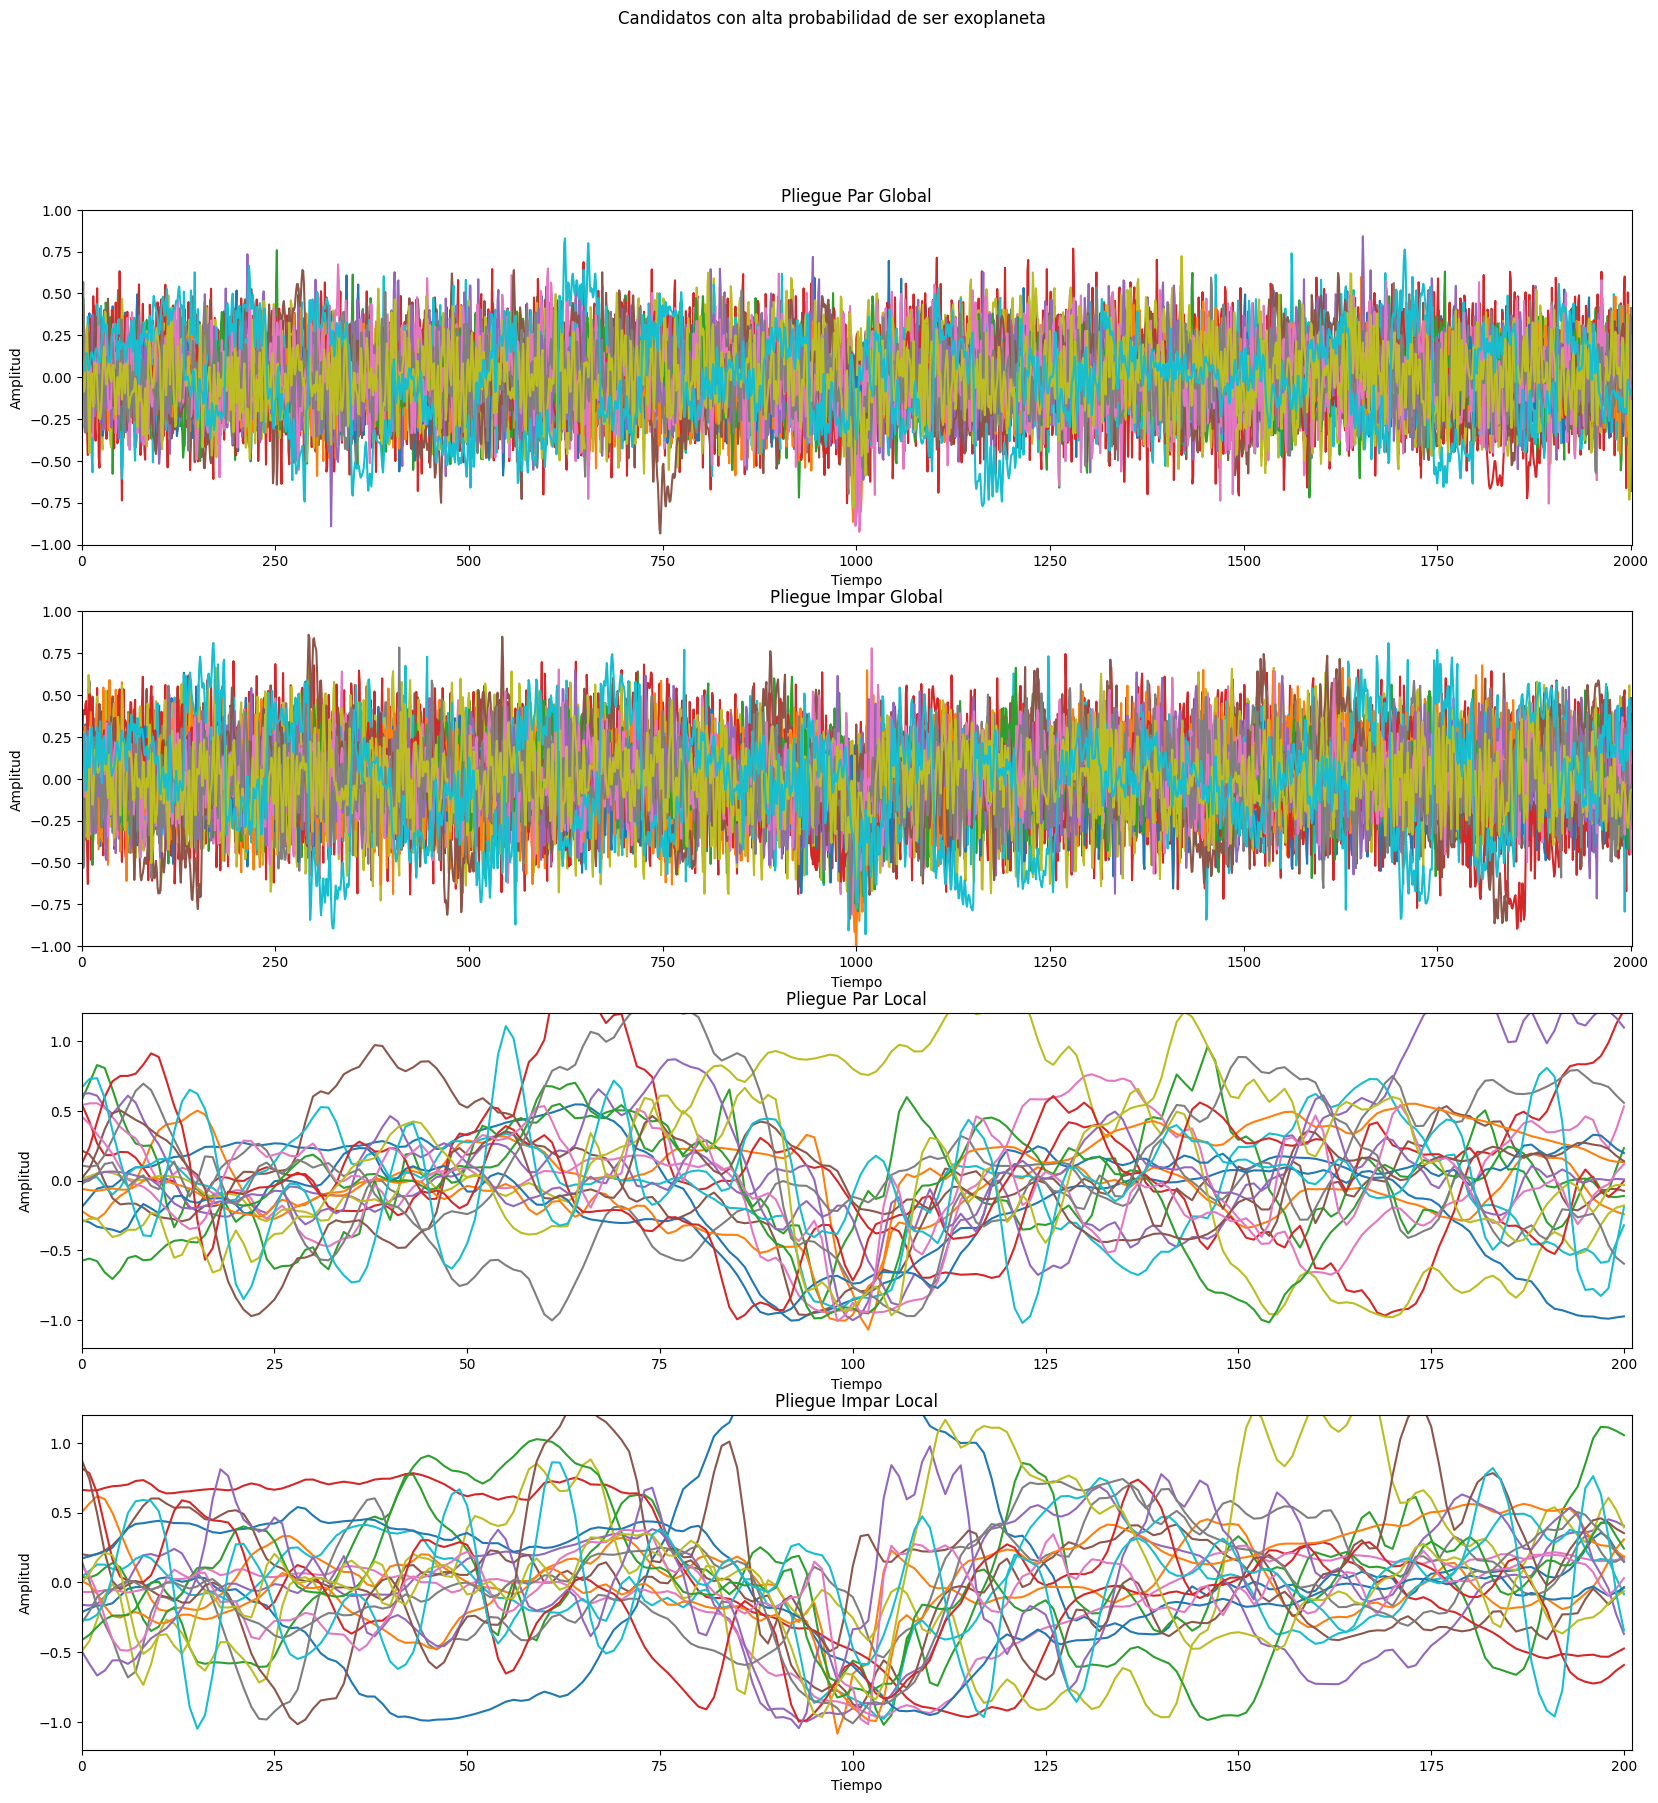

In [50]:
# plot de varios candidatos con alta probabilidad en una misma figura
level = 1
lista_alta_prob = alta_prob['kepler_name'].values[:20]

# cargar los pickles
alta_prob_data_list = [LCWavelet.LightCurveWaveletGlobalLocalCollection.from_pickle(os.path.join(all_data_path, files_dict[name])) for name in lista_alta_prob]


fig, axs = plt.subplots(4, 1, figsize=(20, 20))
for i, data in enumerate(alta_prob_data_list):
    axs[0].plot(data.pliegue_par_global.get_approximation_coefficent(level))
    axs[0].set_xlim(0, 2001)
    axs[0].set_ylim(-1, 1)
    axs[0].set_title('Pliegue Par Global')
    axs[0].set_xlabel('Tiempo')
    axs[0].set_ylabel('Amplitud')
    axs[1].plot(data.pliegue_impar_global.get_approximation_coefficent(level))
    axs[1].set_xlim(0, 2001)
    axs[1].set_ylim(-1, 1)
    axs[1].set_title('Pliegue Impar Global')
    axs[1].set_xlabel('Tiempo')
    axs[1].set_ylabel('Amplitud')
    axs[2].plot(data.pliegue_par_local.get_approximation_coefficent(level))
    axs[2].set_xlim(0, 201)
    axs[2].set_ylim(-1.2, 1.2)
    axs[2].set_title('Pliegue Par Local')
    axs[2].set_xlabel('Tiempo')
    axs[2].set_ylabel('Amplitud')
    axs[3].plot(data.pliegue_impar_local.get_approximation_coefficent(level))
    axs[3].set_xlim(0, 201)
    axs[3].set_ylim(-1.2, 1.2)
    axs[3].set_title('Pliegue Impar Local')
    axs[3].set_xlabel('Tiempo')
    axs[3].set_ylabel('Amplitud')
fig.suptitle('Candidatos con alta probabilidad de ser exoplaneta')
# plt.tight_layout()
plt.show()

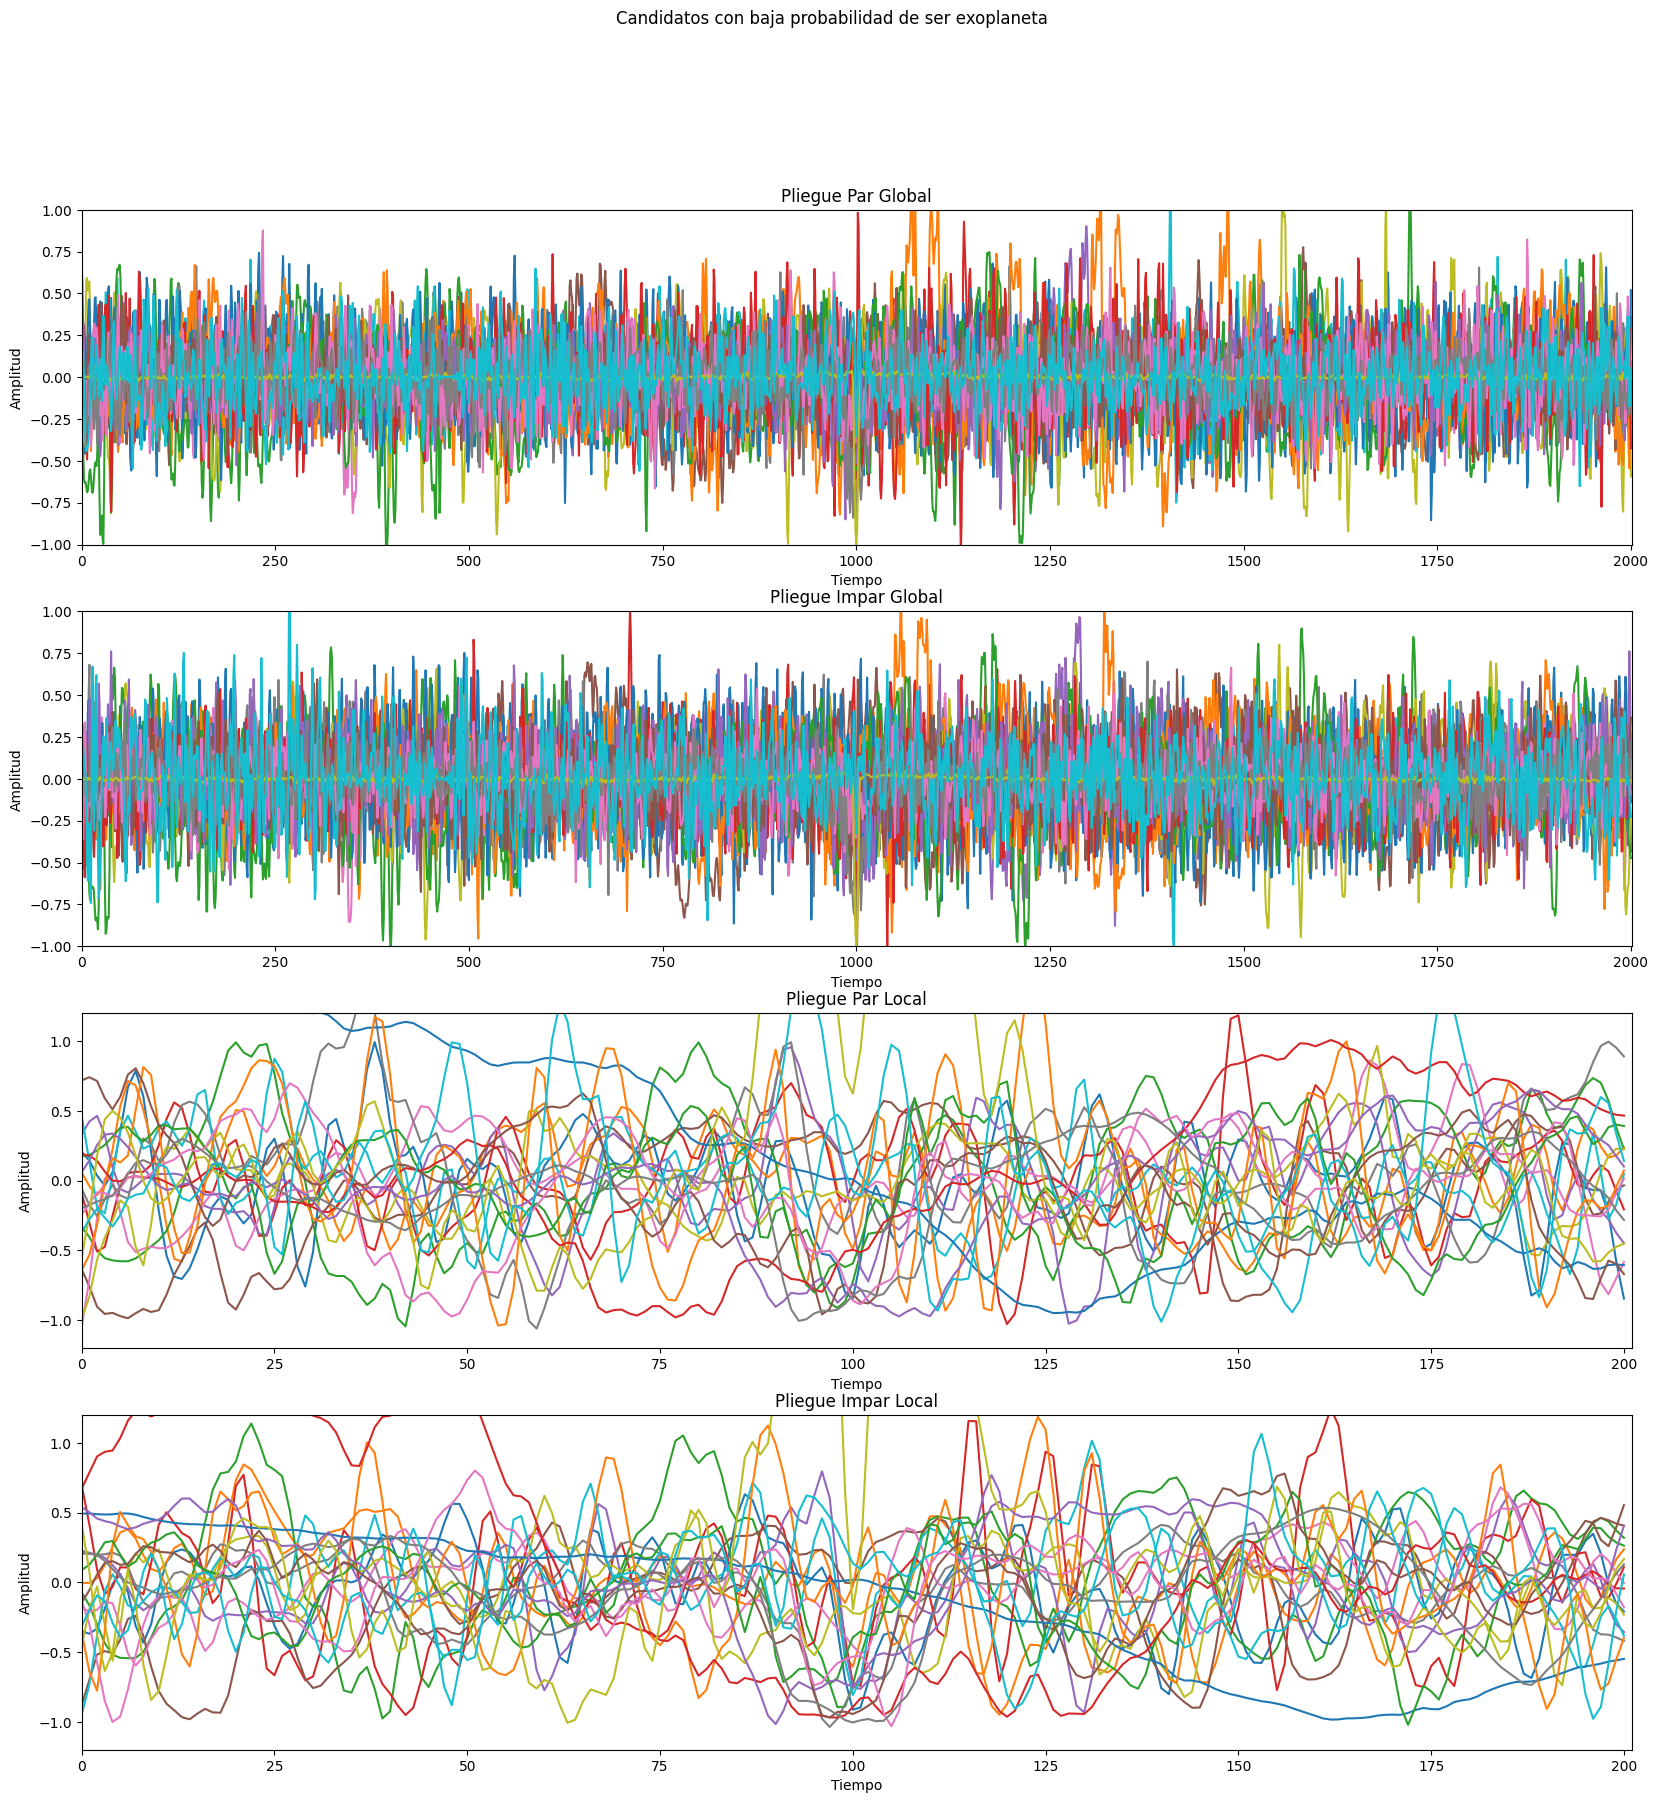

In [51]:
lista_baja_prob = baja_prob['kepler_name'].values[:20]

# cargar los pickles
baja_prob_data_list = [LCWavelet.LightCurveWaveletGlobalLocalCollection.from_pickle(os.path.join(all_data_path, files_dict[name])) for name in lista_baja_prob]
fig, axs = plt.subplots(4, 1, figsize=(20, 20))
for i, data in enumerate(baja_prob_data_list):
    axs[0].plot(data.pliegue_par_global.get_approximation_coefficent(level))
    axs[0].set_xlim(0, 2001)
    axs[0].set_ylim(-1, 1)
    axs[0].set_title('Pliegue Par Global')
    axs[0].set_xlabel('Tiempo')
    axs[0].set_ylabel('Amplitud')
    axs[1].plot(data.pliegue_impar_global.get_approximation_coefficent(level))
    axs[1].set_xlim(0, 2001)
    axs[1].set_ylim(-1, 1)
    axs[1].set_title('Pliegue Impar Global')
    axs[1].set_xlabel('Tiempo')
    axs[1].set_ylabel('Amplitud')
    axs[2].plot(data.pliegue_par_local.get_approximation_coefficent(level))
    axs[2].set_xlim(0, 201)
    axs[2].set_ylim(-1.2, 1.2)
    axs[2].set_title('Pliegue Par Local')
    axs[2].set_xlabel('Tiempo')
    axs[2].set_ylabel('Amplitud')
    axs[3].plot(data.pliegue_impar_local.get_approximation_coefficent(level))
    axs[3].set_xlim(0, 201)
    axs[3].set_ylim(-1.2, 1.2)
    axs[3].set_title('Pliegue Impar Local')
    axs[3].set_xlabel('Tiempo')
    axs[3].set_ylabel('Amplitud')
fig.suptitle('Candidatos con baja probabilidad de ser exoplaneta')
# plt.tight_layout()
plt.show()